# ***Transfer Learning***

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

La transferencia de conocimiento en AI consiste en tomar un modelo entrenado para una tarea en particular, y adaptarlo a una tarea específica. Básicamente no entrenamos un modelo desde cero, partimos de unas caracteristicas aprendidas por un modelo en otra tarea realizada.

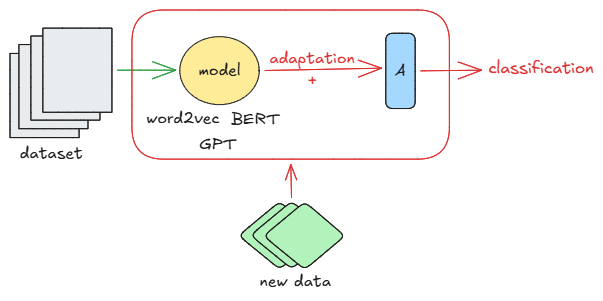

Con el uso de la transferencia de aprendizaje,logramos reducir los siguientes factores:
- Entrenar modelos desde cero con millones de datos
- Computo, GPUs costosas.
- Huella ambiental

## ¿Cómo puedo implementar Transfer Learning?

1. Definir la tarea a resolver
2. Buscar por un modelo ya entrenado que tenga similitud con la tarea a realizar.
3. Los recursos computacionales con los que contamos: memoria, cpu, etc.

Para este notebook estaremos utilizando modelos ya entrenamos, los cuales han sido disponibilizados en [hugging face](https://huggingface.co/welcome). EL principal repositorio de AI.

In [ ]:
from transformers import pipeline

pipe = pipeline("text-generation", model="EleutherAI/gpt-neo-125m")
messages = [
    {"role": "user", "content": "Who are you?"},
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
pipe("EleutherAI has", do_sample=True, min_length=20)

Passing `generation_config` together with generation-related arguments=({'min_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "EleutherAI has been shown to be a useful tool for developing a large-scale web-based database of information about the universe, but is not yet fully developed. The current version of the web-based database is a web-based database of information about various galaxies. In particular, there is no way for a user to get the information about galaxies that is stored in the database. This is due to the lack of a database of galaxies for which the user needs to type in some information about the galaxy. Therefore, it would be desirable to provide a web-based database of galaxies that is not completely developed.\nThe search engine of the search engine is a web-based search engine that searches through selected objects in user data. The search engine is not a database of galaxies but a web-based search engine of a web-based database of galaxies. A search engine is an engine that searches through the user data, including information about galaxies and galaxies' distances.\

### Ejemplo de *transfer learning*

Para este ejemplo utilizaremos un conjunto de datos recolectados y etiquetados en base a comentarios positivos (1), negativo (0)

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
import pandas as pd

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [ ]:
sum(test_df["label"] == 0),sum(test_df["label"] == 1 )

(12500, 12500)

### Modelo base

Como modelo base utilizaremos el [***universal-sentence-encoder***](https://www.kaggle.com/models/google/universal-sentence-encoder/tensorFlow2/universal-sentence-encoder/2?tfhub-redirect=true), el cual fue entrenado para capturar relaciones semánticas en sentencias:

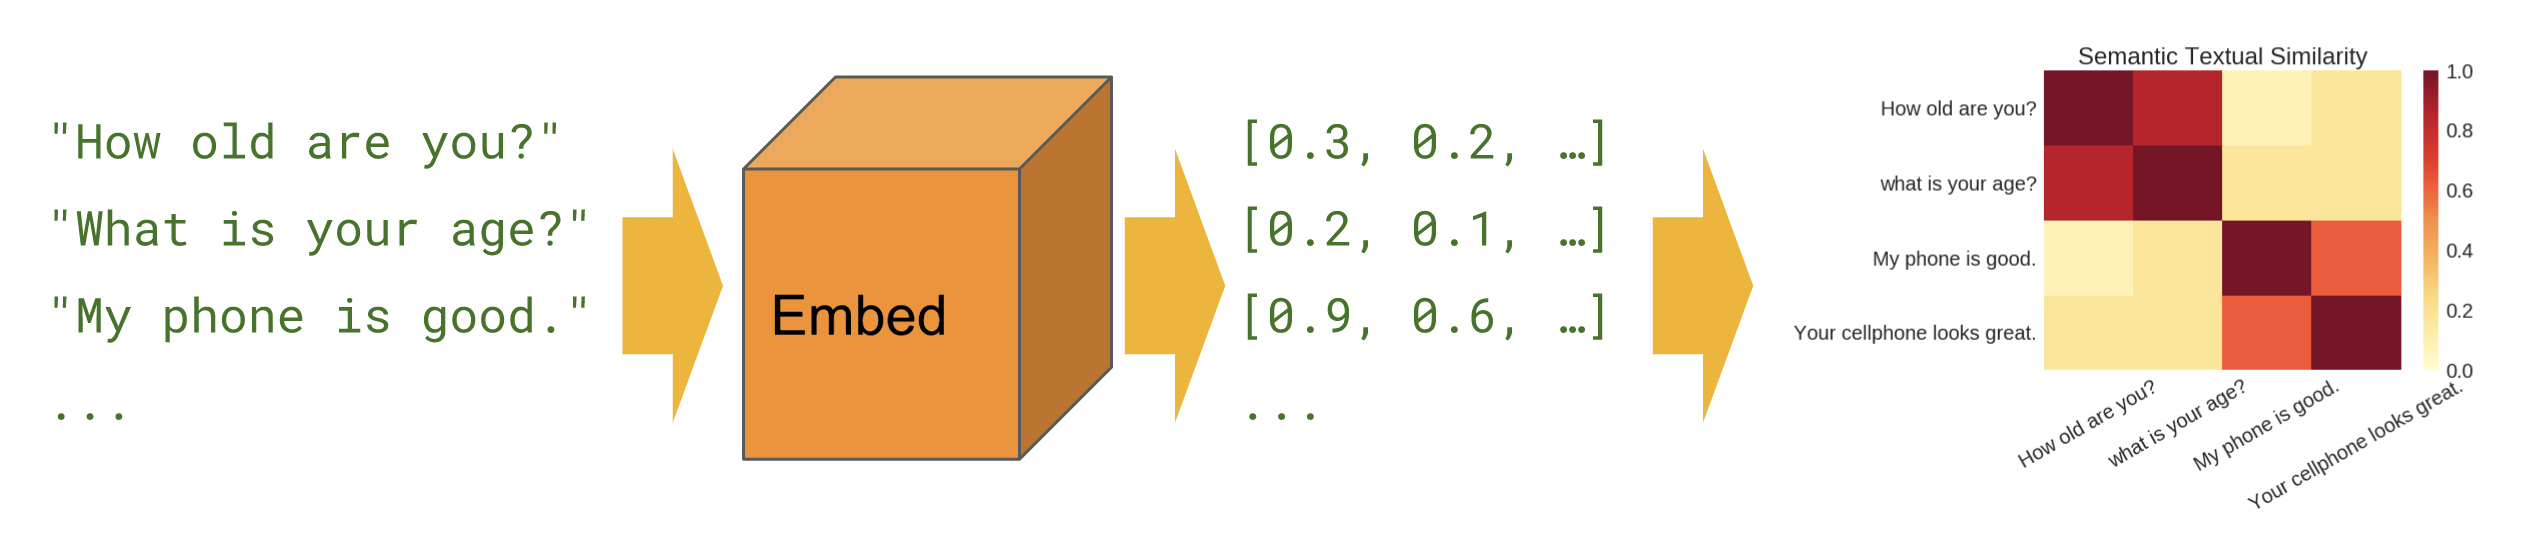

Debido a esta captura de relaciones semánticas en sentencias de diferente longitud. El *embedding* generado (de 512 caracteristicas), logra capturar dichas relaciones para diferentes nuevas tareas de clasificación.

In [ ]:
import tensorflow as tf

BATCH_SIZE = 256

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["text"].values,
        train_df["label"].values
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["text"].values,
        test_df["label"].values
    )
)

train_ds = train_ds.shuffle(300).batch(BATCH_SIZE)
test_ds = test_ds.shuffle(300).batch(BATCH_SIZE)

In [ ]:
import tensorflow_hub as hub

In [ ]:
class HubEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, hub_url, **kwargs):
        super(HubEmbeddingLayer, self).__init__(**kwargs)
        self.hub_layer = hub.KerasLayer(hub_url, input_shape=[], dtype=tf.string, trainable=True)

    def call(self, inputs):
        return self.hub_layer(inputs)

hub_layer = HubEmbeddingLayer("https://tfhub.dev/google/universal-sentence-encoder/4")
#https://tfhub.dev/google/nnlm-en-dim50/2

In [ ]:
input_text = tf.keras.Input(shape=(), dtype=tf.string)
embedding = hub_layer(input_text)
x = tf.keras.layers.Dense(128, activation='relu')(embedding)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=input_text, outputs=output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hub_embedding_layer             │ (None, 512)            │             0 │
│ (HubEmbeddingLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,793 (257.00 KB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Accuracy:", accuracy)

98/98 ━━━━━━━━━━━━━━━━━━━━ 47s 470ms/step - accuracy: 0.5471 - loss: 0.6900
Accuracy: 0.5471199750900269


In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 107s 959ms/step - accuracy: 0.6664 - loss: 0.7936 - val_accuracy: 0.5035 - val_loss: 0.6875
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.5292 - loss: 0.6437 - val_accuracy: 0.5000 - val_loss: 0.9560
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 94s 966ms/step - accuracy: 0.5835 - loss: 0.7273 - val_accuracy: 0.5128 - val_loss: 0.7554
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 94s 963ms/step - accuracy: 0.6671 - loss: 0.6094 - val_accuracy: 0.5821 - val_loss: 0.6884
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7175 - loss: 0.5576 - val_accuracy: 0.6452 - val_loss: 0.6168
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 94s 960ms/step - accuracy: 0.7433 - loss: 0.5189 - val_accuracy: 0.6572 - val_loss: 0.6238
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 95s 978ms/step - accuracy: 0.7563 - loss: 0.5049 - val_accuracy: 0.6995 - val_loss: 0.5639
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 94s 961ms/step - accuracy: 0.7744 - loss: 0.4764 - val_accurac

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Accuracy:", accuracy)

98/98 ━━━━━━━━━━━━━━━━━━━━ 48s 487ms/step - accuracy: 0.7537 - loss: 0.4914
Accuracy: 0.7536799907684326


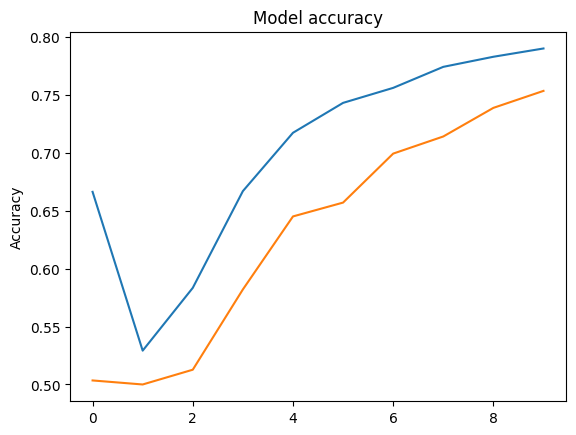

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy');